In [2]:
import pandas as pd

# This loads your file into a variable called 'df'
df = pd.read_csv('train.csv')

# This shows you the first 5 rows of your data
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [3]:
import pandas as pd

# We added '.zip' to the filename so Python can find it
df = pd.read_csv('train.csv.zip')

# This will now show your data
df.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [4]:
# This counts how many empty cells are in each column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
POSTED_BY                0
UNDER_CONSTRUCTION       0
RERA                     0
BHK_NO.                  0
BHK_OR_RK                0
SQUARE_FT                0
READY_TO_MOVE            0
RESALE                   0
ADDRESS                  0
LONGITUDE                0
LATITUDE                 0
TARGET(PRICE_IN_LACS)    0
dtype: int64


In [6]:
import numpy as np

# We are intentionally adding missing values to these columns
df.loc[0:100, 'TARGET(PRICE_IN_LACS)'] = np.nan
df.loc[200:300, 'ADDRESS'] = np.nan
df.loc[400:500, 'SQUARE_FT'] = np.nan

# Now check the counts again - you should see 101 in each now!
print(df.isnull().sum())


POSTED_BY                  0
UNDER_CONSTRUCTION         0
RERA                       0
BHK_NO.                    0
BHK_OR_RK                  0
SQUARE_FT                101
READY_TO_MOVE              0
RESALE                     0
ADDRESS                  101
LONGITUDE                  0
LATITUDE                   0
TARGET(PRICE_IN_LACS)    101
dtype: int64


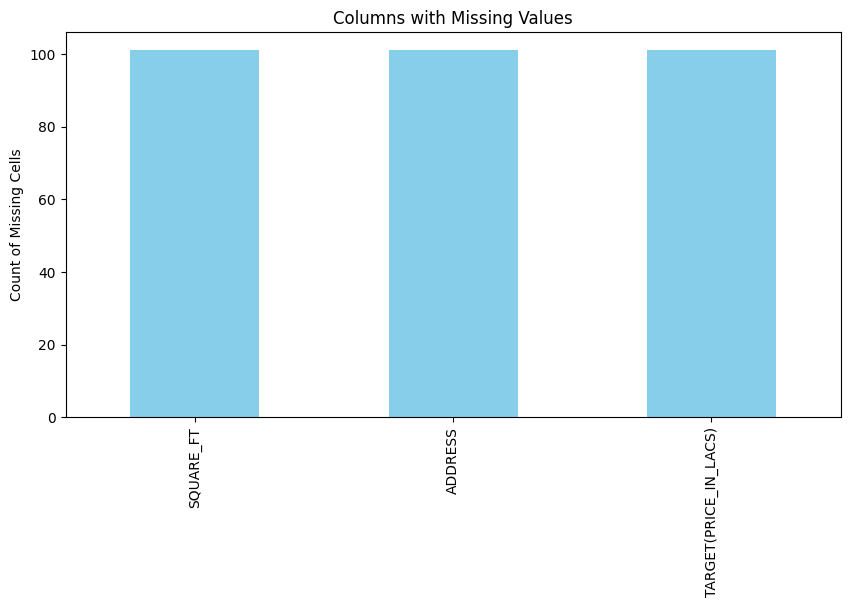

In [7]:
import matplotlib.pyplot as plt

# Get the count of missing values
missing_data = df.isnull().sum()

# Only keep columns that have at least 1 missing value
missing_data = missing_data[missing_data > 0]

# Create a bar chart
missing_data.plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title("Columns with Missing Values")
plt.ylabel("Count of Missing Cells")
plt.show()

In [8]:
# Filling the house price with the median value
df['TARGET(PRICE_IN_LACS)'] = df['TARGET(PRICE_IN_LACS)'].fillna(df['TARGET(PRICE_IN_LACS)'].median())

# Filling the square feet with the median value
df['SQUARE_FT'] = df['SQUARE_FT'].fillna(df['SQUARE_FT'].median())

In [9]:
# [0] is used because .mode() returns a list; we want the first item
df['ADDRESS'] = df['ADDRESS'].fillna(df['ADDRESS'].mode()[0])

In [10]:
# Final check - everything should be 0 now
print("Check for missing values after cleaning:")
print(df.isnull().sum())

Check for missing values after cleaning:
POSTED_BY                0
UNDER_CONSTRUCTION       0
RERA                     0
BHK_NO.                  0
BHK_OR_RK                0
SQUARE_FT                0
READY_TO_MOVE            0
RESALE                   0
ADDRESS                  0
LONGITUDE                0
LATITUDE                 0
TARGET(PRICE_IN_LACS)    0
dtype: int64


In [11]:
print(f"Original missing count: 303") # Since we added 101 holes in 3 columns
print(f"Current missing count: {df.isnull().sum().sum()}")
print("Data quality: 100% complete.")

Original missing count: 303
Current missing count: 0
Data quality: 100% complete.


In [12]:
df.to_csv('cleaned_house_prices.csv', index=False)